In [ ]:
# Montar Google Drive para acceder a los archivos del curso
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

df_biovid = pd.read_csv('/content/drive/Shareddrives/DATA_GPI/Grupo2_Desarrollo/dataset_features_biovid.csv')

caracteristicas_cuerpo = ['ecg_bpm', 'gsr_peaks_count', 'gsr_max_amplitude',
                          'emg_trapezius_mean', 'emg_corrugator_mean', 'emg_zygomaticus_mean']
X = df_biovid[caracteristicas_cuerpo]

matriz_corr = X.corr().abs()
superior = matriz_corr.where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))
variables_a_eliminar = [columna for columna in superior.columns if any(superior[columna] > 0.85)]

print("Variables con correlación > 0.85 (redundantes):")
print(variables_a_eliminar)

print("\nPares que superaron el umbral de 0.85:")
for col in superior.columns:
    for idx in superior.index:
        val = superior.loc[idx, col]
        if pd.notna(val) and val > 0.85:
            print(f"  {idx} ↔ {col}: r = {val:.4f}")

# Las siguientes líneas ejecutan la exclusión por redundancia
# X_filtrado = X.drop(columns=variables_a_eliminar)
# print(f"Columnas restantes: {X_filtrado.columns.tolist()}")

print("\nColumnas que SOBREVIVIRÍAN al filtro:")
sobrevivientes = [col for col in caracteristicas_cuerpo if col not in variables_a_eliminar]
print(sobrevivientes)

Variables con correlación > 0.85 (redundantes):
[]

Pares que superaron el umbral de 0.85:

Columnas que SOBREVIVIRÍAN al filtro:
['ecg_bpm', 'gsr_peaks_count', 'gsr_max_amplitude', 'emg_trapezius_mean', 'emg_corrugator_mean', 'emg_zygomaticus_mean']


Columnas sobrevivientes al filtro Pearson: ['ecg_bpm', 'gsr_peaks_count', 'gsr_max_amplitude', 'emg_trapezius_mean', 'emg_corrugator_mean', 'emg_zygomaticus_mean']

RANKING OFICIAL DE CARACTERÍSTICAS CORPORALES VIP:
     Sensor_Corporal  Puntaje_MI
 emg_corrugator_mean    0.020472
  emg_trapezius_mean    0.015642
             ecg_bpm    0.008668
     gsr_peaks_count    0.008238
emg_zygomaticus_mean    0.003565
   gsr_max_amplitude    0.000000


/tmp/ipykernel_3174/3536457780.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


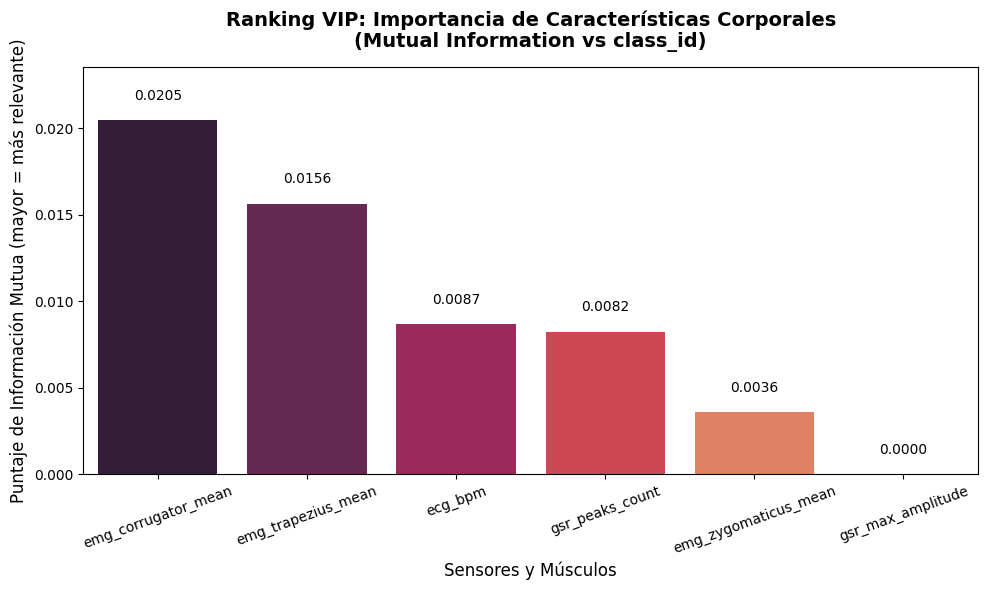

Grafico guardado como: ranking_vip.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import os

# ─── OPCIÓN 2: INFORMACIÓN MUTUA Y RANKING VIP ───────────────────────────────
from sklearn.feature_selection import mutual_info_classif

# Construir el conjunto filtrado a partir de lo calculado en Opción 1
filtered_features = X.drop(columns=variables_a_eliminar)
print(f"Columnas sobrevivientes al filtro Pearson: {filtered_features.columns.tolist()}")

# Extraer la variable objetivo
pain_labels = df_biovid['class_id']

# Calcular Información Mutua
mutual_info_scores = mutual_info_classif(filtered_features, pain_labels, random_state=42)

# Construir DataFrame de ranking ordenado de mayor a menor
df_vip_ranking = pd.DataFrame({
    'Sensor_Corporal': filtered_features.columns,
    'Puntaje_MI': mutual_info_scores
}).sort_values(by='Puntaje_MI', ascending=False).reset_index(drop=True)

print("\nRANKING OFICIAL DE CARACTERÍSTICAS CORPORALES VIP:")
print(df_vip_ranking.to_string(index=False))

# ─── GRÁFICO RANKING VIP ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Gráfico de barras verticales: el eje X muestra los sensores,
# el eje Y muestra el puntaje de Información Mutua
sns.barplot(
    x='Sensor_Corporal',
    y='Puntaje_MI',
    data=df_vip_ranking,
    palette='rocket',
    ax=ax
)

# Anotar el valor exacto sobre el tope de cada barra
for bar in ax.patches:
    bar_height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # centrado horizontal dentro de la barra
        bar_height + 0.001,                  # justo encima del tope de la barra
        f'{bar_height:.4f}',
        va='bottom', ha='center', fontsize=10
    )

# Fijar limite del eje Y DESPUES de las anotaciones
maximum_value = df_vip_ranking['Puntaje_MI'].max()
ax.set_ylim(0, maximum_value * 1.15)

ax.set_title(
    'Ranking VIP: Importancia de Características Corporales\n(Mutual Information vs class_id)',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Sensores y Músculos', fontsize=12)
ax.set_ylabel('Puntaje de Información Mutua (mayor = más relevante)', fontsize=12)
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('ranking_vip.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico guardado como: ranking_vip.png")
